# 상품 주문으로 설명하는 DB 발표

**실행 순서:** 준비 → 로그인 → 상품 확인/등록 → 주문 → 연결 확인 → 배송중 수정 → 관리자 조회 → DB 개념 시연.

위에서부터 **코드 셀을 하나 실행하고 바로 아래 Markdown 설명을 읽는다.** 앞 셀의 변수를 다음 셀에서 이어 사용한다. 회원 계정과 같은 ID의 `user_details` 행은 미리 준비한다. 예제에서는 준비한 실습 계정으로 판매와 주문을 함께 시연한다.

기존 클래스와 import를 그대로 사용한다. 생성/수정된 테이블은 Supabase Table Editor에서 직접 확인한다. 주문 셀을 다시 실행하면 새 주문이 한 건 더 만들어진다. 아래 관리자 조회는 현재 연결로 읽을 수 있는 데이터 기준이며 권한을 바꾸는 기능이 아니다.

발표 범위는 1~6번이다. DDL/DML 독립 설명과 7번은 제외한다. SQL 코드 블록은 설명용이며 **Supabase SQL Editor에서 실행**한다. Python 셀에서 SQL 문자열을 출력한 것만으로 DB에 실행되지는 않는다.

In [ ]:
%run ./users.ipynb
%run ./products.ipynb
%run ./orders.ipynb
%run ./order_items.ipynb

user_service = UserService(supabase)
order_service = Order_service(supabase)
order_item_service = OrderItemService(supabase)

## 준비. 기존 노트북 불러오기

기존 파일에 있는 연결 코드와 클래스를 사용한다. `products.ipynb` 전체에는 별도의 로그인 실습이 있으므로 실행하지 않고, 상품 조회/등록만 여기서 짧게 작성한다.

In [ ]:
email = input("실습 계정 이메일: ")
password = input("실습 계정 비밀번호: ")

login = supabase.auth.sign_in_with_password({
    "email": email, "password": password
})

user_id = login.user.id
password = None

print("로그인한 회원 ID:", user_id)
user_detail = user_service.get_active_user_by_id(user_id)
print("회원 상세정보:", [{"id": row["id"], "type": row["type"]} for row in user_detail])
product_manager = product_service(supabase)

## 시연 A. 로그인

GUI의 로그인 폼에 해당한다. 로그인 결과의 사용자 ID를 주문자 ID로 사용한다. 입력한 비밀번호와 로그인 응답 전체는 출력하지 않는다.

In [ ]:
product_name = "발표용 머그컵"
products = [row for row in product_manager.get_product(product_name)
            if row["name"] == product_name]

print("상품 있음" if products else "상품 없음: 새로 등록합니다.")
if not products:
    products = product_manager.new_product(product_name, 12000, "발표용 상품")

product = products[0]
print(product)

## 시연 B. 상품이 있는지 확인하고 없으면 등록

상품명으로 조회하고 결과 리스트가 비었으면 실습용 상품 한 건을 만든다. `seller_id`는 `user_details.id`를 참조하므로 앞에서 준비한 회원 ID를 넣는다. 등록 후 `products` 테이블을 직접 확인한다.

In [ ]:
quantity = 2

orders = order_service.create_order({
    "order_no": f"EX-{uuid.uuid4().hex}",
    "order_name": "발표용 주문자",
    "user_id": user_id,
    "total_price": product["price"] * quantity,
    "order_status": "ORDER",
})

order_id = orders[0]["id"]

items = order_item_service.create_order_item(
    order_id, product["id"], product["name"], product["price"], quantity
)

print("주문 ID:", order_id)
print(items)

## 시연 C. 상품 주문

먼저 `orders`를 만들고, 반환된 주문 ID와 상품 ID를 `order_items`에 넣는다. 이 셀 한 번이 주문하기 버튼이다. `order_no`와 `order_name`은 실제 테이블의 필수값이며, 주문번호에는 기존 노트북에서 불러온 `uuid`를 사용한다.

**Supabase 확인:** `orders.id = order_items.order_id`, `products.id = order_items.product_id`가 각각 같은지 보여준다. 상품 원본이 하나 더 생기는 것이 아니라 **주문상품 행**이 생긴다.

주문 상태 `ORDER`는 주문 접수를 뜻한다. `order_items`의 `item_name`, `item_price`는 주문 당시 이름과 가격을 남긴다. 상품 원본을 나중에 수정해도 과거 주문 금액을 설명할 수 있다.

In [ ]:
ordered_items = (supabase.table("order_items")
                        .select("*")
                        .eq("order_id", order_id)
                        .eq("product_id", product["id"])
                        .is_("deleted_at", "null").execute().data
)

print("주문상품 있음" if ordered_items else "주문상품 없음")
print(ordered_items)

## 시연 D. 주문에 해당 상품이 들어갔는지 확인

주문 ID와 상품 ID로 조회한다. 결과가 있으면 이 주문에 해당 상품이 연결된 것이다.

In [ ]:
updated_order = order_service.update_order_status(user_id, order_id, "ON_DELIVERY")

print(updated_order)

## 시연 E. 배송중으로 수정

배송이 시작됐다고 가정하고 기존 메서드로 **상품이 아니라 주문의 상태**를 바꾼다. Supabase의 `orders.order_status`가 `ORDER`(주문 접수)에서 `ON_DELIVERY`(배송중)로 바뀌는지 확인한다.

**발표:** “배송 상태는 주문에 속한 정보이므로 products가 아니라 orders를 수정했습니다.”

## 1. 테이블 관계 표현

담당: 이승주, 배서인, 서종찬, 양석호

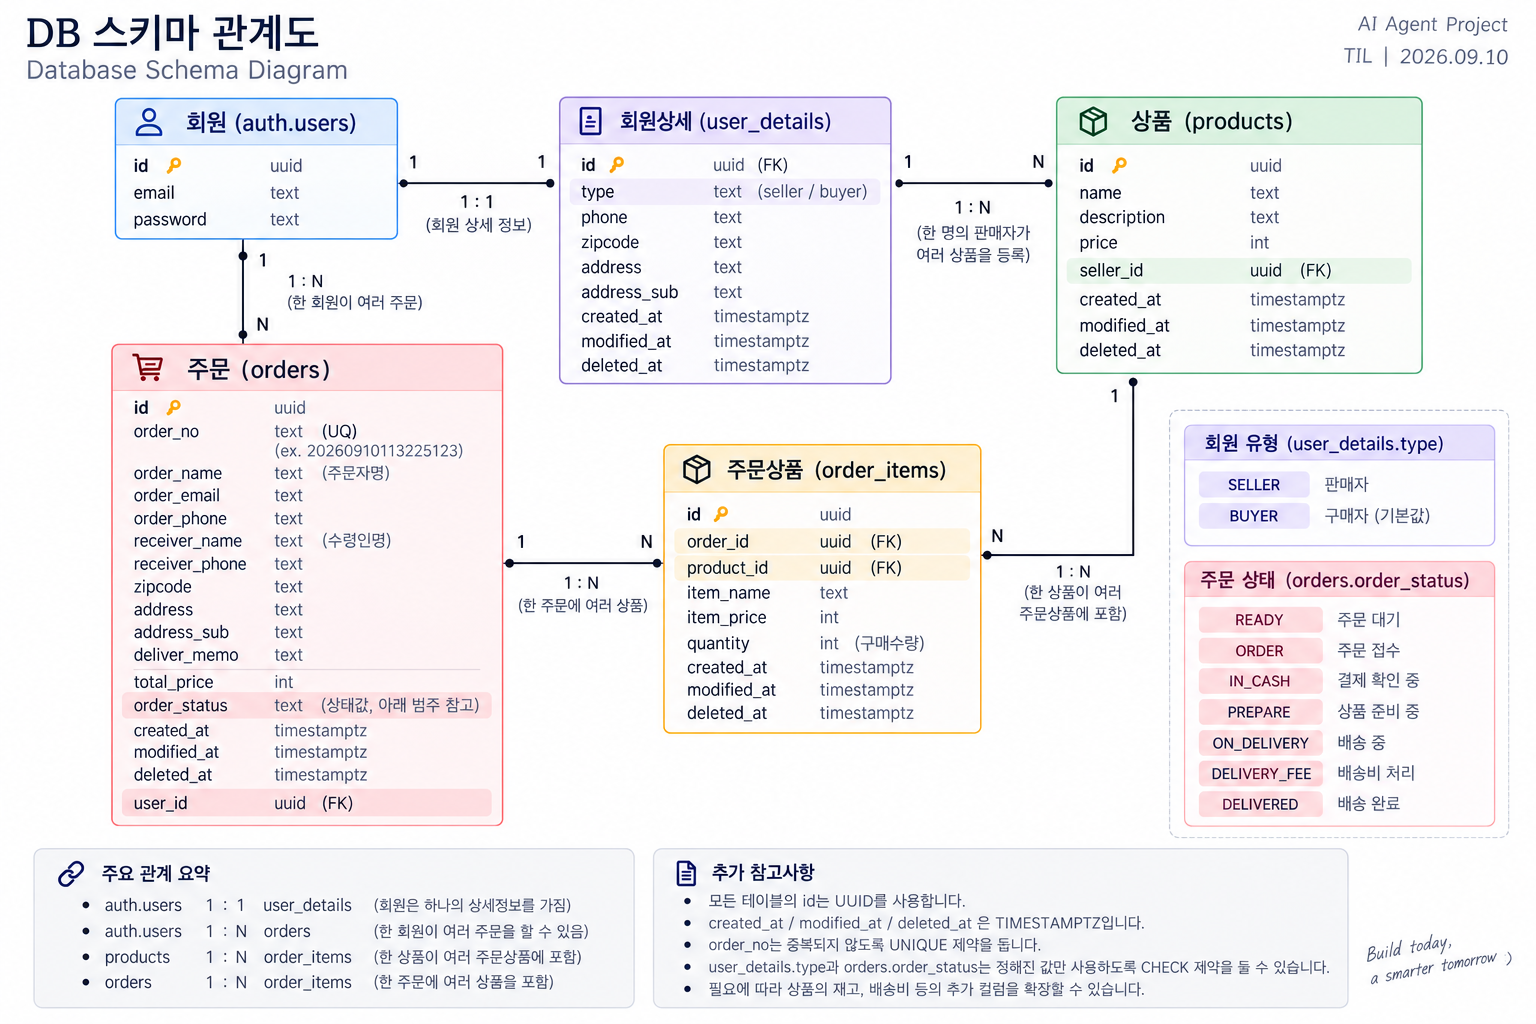

사진에서 **orders → order_items ← products**를 짚으며 방금 만든 두 ID를 설명하면 된다.

- `auth.users → user_details`: 상세정보의 PK가 회원 ID를 참조해서 회원당 **최대 한 행**이다. 상세정보가 반드시 자동 생성된다는 뜻은 아니다.
- `auth.users → orders`: 회원 한 명이 여러 주문을 할 수 있다.
- `user_details → products`: 판매자 한 명이 여러 상품을 등록할 수 있다. FK는 회원 상세정보의 존재를 보장하지만 SELLER 유형까지 자동 검사하지는 않는다.
- `orders → order_items`, `products → order_items`: 각각 1:N이다. 주문과 상품의 N:M 관계를 주문상품 테이블로 풀어낸다.

**발표:** “주문은 주문 전체 정보, 주문상품은 어떤 상품을 몇 개 샀는지입니다. order_id와 product_id로 두 테이블을 연결합니다.”

사진의 auth.users 비밀번호 표기는 개념도다. 비밀번호를 일반 text 컬럼에 직접 저장하는 예제가 아니라 Supabase Auth가 인증을 처리한다.

In [ ]:
admin_orders = (supabase.table("orders")
    .select("id,order_no,total_price,order_status")
    .is_("deleted_at", "null").execute().data)
admin_products = (supabase.table("products")
    .select("id,name,price").is_("deleted_at", "null").execute().data)
admin_items = (supabase.table("order_items")
    .select("order_id,product_id,quantity,item_price")
    .is_("deleted_at", "null").execute().data)

print("[관리자 조회] 주문", len(admin_orders), "건 / 상품", len(admin_products), "개")
for row in admin_orders:
    print(row["order_no"], row["order_status"], row["total_price"])

## 2. 데이터 집계함수: 관리자 조회 준비

담당: 오명석, 양석호

주문자 한 명의 화면에서 **조회 가능한 전체 주문을 보는 관리자 화면**으로 관점을 바꾼다. 삭제되지 않은 주문, 상품, 주문상품만 읽고 이후 예제에서 재사용한다. DB가 바뀌면 이 셀부터 다시 실행해 최신 데이터를 읽는다.

`admin_orders`는 주문 목록, `admin_products`는 상품 목록, `admin_items`는 주문에 들어간 상품 목록이다. 실습 데이터가 적으면 결과가 한 줄만 나오는 것이 정상이다. SDK 기본 조회 한도를 넘는 대규모 데이터의 전수 집계까지 구현한 예제는 아니다.

In [ ]:
print(f"{'상태':<16} {'COUNT':>6} {'SUM':>10} {'AVG':>10} {'MIN':>10} {'MAX':>10}")
for status in sorted({row["order_status"] or "미지정" for row in admin_orders}):
    rows = [row for row in admin_orders if (row["order_status"] or "미지정") == status]
    amounts = [row["total_price"] for row in rows if row["total_price"] is not None]
    total = sum(amounts) if amounts else None
    average = round(total / len(amounts), 2) if amounts else None
    print(f"{status:<16} {len(rows):>6} {str(total):>10} {str(average):>10} "
          f"{str(min(amounts, default=None)):>10} {str(max(amounts, default=None)):>10}")

### 실행 결과 설명: 상태별 주문 건수와 금액

COUNT는 건수, SUM은 합계, AVG는 평균, MIN/MAX는 최소/최대 주문 금액이다. 위 셀은 SDK로 받은 행을 **Python으로 집계**했다. `amounts`에서 None을 제외해 SQL 집계함수가 NULL을 제외하는 의미를 맞춘다. COUNT(*)는 금액이 없어도 주문 행을 센다.

같은 작업을 DB의 집계함수로 직접 실행하려면 아래 SQL을 사용한다.

```sql
SELECT order_status, COUNT(*) AS order_count,
       SUM(total_price) AS total_amount,
       ROUND(AVG(total_price), 2) AS average_amount,
       MIN(total_price) AS minimum_amount,
       MAX(total_price) AS maximum_amount
FROM orders
WHERE deleted_at IS NULL
GROUP BY order_status;
```

**발표:** “관리자는 GROUP BY로 배송 상태별 주문 수와 금액을 볼 수 있습니다. 머그컵이 12,000원이고 2개 주문했다면 해당 주문 금액은 24,000원입니다. 여기의 합계는 주문 금액이며 결제 완료 매출로 확정한 값은 아닙니다.”

In [ ]:
joined_orders = (supabase.table("orders")
    .select("order_no,order_status,order_items(item_name,item_price,quantity,products(name))")
    .is_("deleted_at", "null")
    .is_("order_items.deleted_at", "null")
    .execute().data)

for order in joined_orders:
    for item in order["order_items"]:
        current_product = item["products"]
        current_name = current_product["name"] if current_product else "연결 상품 없음"
        print(order["order_no"], order["order_status"], current_name,
              "수량:", item["quantity"], "주문금액:", item["item_price"] * item["quantity"])

## 3. 집합과 조인: JOIN으로 주문 상세 보기

담당: 장예지, 양석호

`orders → order_items → products`의 FK를 따라 관련 데이터를 한 요청으로 읽는다. Supabase는 연결 결과를 중첩된 리스트/딕셔너리로 반환한다. 바깥 반복문은 주문, 안쪽 반복문은 그 주문의 상품이다.

위 SDK 조회는 기본적으로 부모 행을 유지하는 관계 조회다. 주문상품이 없는 주문은 빈 리스트여서 출력 반복문에는 표시되지 않는다. SQL INNER JOIN 자체를 실행한 것과 응답 구조까지 같다고 설명하지 않는다.

```sql
SELECT o.order_no, o.order_status, p.name,
       oi.quantity, oi.item_price * oi.quantity AS item_total
FROM orders o
JOIN order_items oi ON oi.order_id = o.id
LEFT JOIN products p ON p.id = oi.product_id
WHERE o.deleted_at IS NULL AND oi.deleted_at IS NULL;
```

**발표:** “JOIN은 관련 있는 테이블의 컬럼을 연결합니다. 주문번호 옆에 상품명과 수량을 붙여 관리자 주문 상세 화면을 만들었습니다. INNER JOIN은 연결된 행만, LEFT JOIN은 왼쪽 행도 유지합니다.”

In [ ]:
registered_ids = {row["id"] for row in admin_products}
ordered_ids = {row["product_id"] for row in admin_items}

print("UNION 합집합:", registered_ids | ordered_ids)
print("INTERSECT 교집합, 등록돼 있고 주문된 상품:", registered_ids & ordered_ids)
print("EXCEPT 차집합, 등록돼 있지만 주문되지 않은 상품:", registered_ids - ordered_ids)
print("UNION ALL, 중복 유지:",
      [row["id"] for row in admin_products] + [row["product_id"] for row in admin_items])

### 집합: 등록 상품과 주문된 상품 비교

두 목록의 **같은 종류 값인 상품 ID**를 비교한다. Python set은 중복을 제거한다. `|`는 합집합, `&`는 교집합, `-`는 차집합이며, 리스트를 더하면 중복을 유지한다.

```sql
SELECT id FROM products WHERE deleted_at IS NULL
INTERSECT
SELECT product_id FROM order_items WHERE deleted_at IS NULL;
```

`INTERSECT` 자리에 `UNION`, `UNION ALL`, `EXCEPT`를 넣어 각각 시연할 수 있다. 집합 SQL은 양쪽 컬럼 수와 자료형이 맞아야 한다. 현재 예제는 삭제되지 않은 주문상품 기록 기준이다.

**발표:** “JOIN은 옆으로 정보를 연결하고, 집합은 같은 구조의 결과를 합치거나 비교합니다. 차집합이 비었다면 등록 상품이 모두 현재 주문상품 기록에 등장한다는 뜻입니다.”

In [ ]:
prices = [row["price"] for row in admin_products if row["price"] is not None]
average_price = sum(prices) / len(prices) if prices else None
expensive_products = [row for row in admin_products
    if row["price"] is not None and average_price is not None and row["price"] > average_price]
print("전체 상품 평균 가격:", average_price)
print("평균보다 비싼 상품:", expensive_products)

## 4. 서브쿼리 유형: 평균보다 비싼 상품

담당: 이승주, 장예지, 양석호

안쪽 조회의 결과를 바깥 조회의 조건으로 쓰는 것이 서브쿼리다. 위 Python 코드는 **평균 계산 → 상품 비교**라는 흐름을 풀어 보여준다. 실제 DB에서 아래 SQL을 실행하면 한 쿼리 안에서 처리한다.

```sql
SELECT name, price FROM products
WHERE deleted_at IS NULL
  AND price > (SELECT AVG(price) FROM products WHERE deleted_at IS NULL);
```

안쪽 AVG는 값 하나를 반환하므로 스칼라 서브쿼리다. 바깥 행을 참조하지 않아 비상관 서브쿼리이기도 하다. 상품이 하나뿐이거나 가격이 모두 같으면 평균보다 비싼 상품은 없으므로 빈 리스트가 정상이다.

**발표:** “평균값 하나를 먼저 구하고, 그 값보다 비싼 상품을 고릅니다.”

In [ ]:
ordered_products = [row for row in admin_products if row["id"] in ordered_ids]
print("주문상품 기록에 등장하는 상품:")
for row in ordered_products:
    print(row["name"], row["price"])

### 다중 행 서브쿼리: IN

이번에는 평균 한 개가 아니라 **상품 ID 여러 개**를 조건으로 쓴다. 앞에서 만든 `ordered_ids`에 포함되는 상품만 고른다. 위 코드는 Python으로 결과를 비교한 것이며 SQL 서브쿼리를 서버에 보낸 것은 아니다.

```sql
SELECT name, price FROM products
WHERE deleted_at IS NULL
  AND id IN (SELECT product_id FROM order_items WHERE deleted_at IS NULL);
```

**발표:** “IN은 여러 조회 결과에 포함되는지 확인할 때 사용합니다. 관리자는 어떤 상품이 주문됐는지 볼 수 있습니다.”

In [ ]:
for row in admin_products:
    has_order = any(item["product_id"] == row["id"] for item in admin_items)
    print(row["name"], "주문 기록 있음" if has_order else "주문 기록 없음")

### 상관 서브쿼리: EXISTS

상품을 하나씩 보며 그 상품 ID와 같은 주문상품이 있는지 확인한다. `any()`는 조건을 만족하는 항목이 하나라도 있으면 True다. 이는 EXISTS의 의미를 Python으로 풀어 쓴 예제다.

```sql
SELECT p.name FROM products p
WHERE p.deleted_at IS NULL
  AND EXISTS (
    SELECT 1 FROM order_items oi
    WHERE oi.product_id = p.id AND oi.deleted_at IS NULL
  );
```

안쪽 쿼리가 바깥의 `p.id`를 참조하므로 **상관 서브쿼리**다. SQL 예제는 주문 기록이 있는 상품만 반환하고, 위 Python 출력은 설명을 위해 모든 상품의 있음/없음을 표시한다. DB가 실제로 매번 Python처럼 반복 실행한다고 단정하지 않는다.

스칼라/다중 행은 반환 결과 기준, 상관/비상관은 바깥 쿼리 참조 기준이다. 같은 예제에 여러 분류가 동시에 적용된다.

In [ ]:
transaction_sql = f"""BEGIN;
UPDATE orders SET order_status = 'DELIVERED' WHERE id = '{order_id}';
SELECT id, order_status FROM orders WHERE id = '{order_id}';
ROLLBACK;
SELECT id, order_status FROM orders WHERE id = '{order_id}';"""
print(transaction_sql)

## 5. 트랜잭션(TCL)과 ACID 원칙

담당: 서종찬, 배서인, 장예지, 양석호

위 셀은 방금 만든 주문 ID가 들어간 SQL을 **출력만** 한다. Supabase SQL Editor에 전체를 복사해 실행한다. 트랜잭션 안에서는 `DELIVERED`로 바뀌지만 ROLLBACK 후 마지막 SELECT는 기존 `ON_DELIVERY`를 보여준다. 편집기에서 마지막 결과만 보이더라도 최종 상태로 취소를 확인할 수 있다.

BEGIN은 시작, COMMIT은 확정, ROLLBACK은 취소, SAVEPOINT는 중간 지점이다. 예제는 취소로 끝난다.

- **A 원자성:** 주문과 주문상품이 모두 저장되거나 모두 취소되는 처리 단위.
- **C 일관성:** FK, 양수 수량처럼 정해진 무결성 규칙을 지킴.
- **I 격리성:** 동시에 실행되는 트랜잭션의 간섭을 격리 수준에 따라 제어.
- **D 지속성:** 커밋된 결과를 장애 후에도 보존.

**발표:** “앞의 주문 생성과 주문상품 생성은 별도 API 요청입니다. 하나의 Python 셀에 있어도 하나의 트랜잭션은 아닙니다. 둘을 원자적으로 묶으려면 DB 함수 등 서버 측 처리가 필요합니다. 오늘은 ROLLBACK의 의미만 시연합니다.”

In [ ]:
query = supabase.table("orders").select("id,order_status")
same_query = query.eq("id", order_id)

print("eq()가 원래 객체를 반환했나요?", query is same_query)
print(same_query.is_("deleted_at", "null").execute().data)

## 6. SDK와 메서드 체이닝, LangChain 구분

담당: 배서인, 장예지, 오명석, 양석호

**SDK**는 서비스 기능을 코드로 사용할 수 있게 제공하는 도구다. 이 예제의 Supabase Python SDK는 조회 조건을 모아 API 요청을 보내고 응답을 Python 데이터로 돌려준다.

위 셀에서 `query is same_query`가 True면 **값만 같은 것이 아니라 같은 객체**다. 설치된 PostgREST SDK의 `eq()`는 내부 `filter()`를 호출하고, `filter()`는 조건을 저장한 뒤 `return self`를 한다. 그래서 반환된 객체에 다음 메서드를 이어 호출할 수 있다.

```python
# 동작을 설명하기 위한 축약이며 새 클래스를 추가하지 않는다.
def eq(self, column, value):
    return self.filter(column, "eq", value)

def filter(self, column, operator, value):
    # self에 조회 조건 저장
    return self
```

`table()`이나 `select()`까지 모든 메서드가 같은 self를 돌려준다는 뜻은 아니다. 이 시연은 **eq() 전후의 동일성**을 확인한다. `execute()`는 실제 요청을 보내고 응답 객체를 반환한다.

**메서드 체이닝**은 위처럼 호출을 연결하는 코딩 방식이다. **LangChain**은 LLM과 도구, 검색 등의 흐름을 구성하는 별도 프레임워크다. `return self` 예제를 LangChain 구현이라고 발표하면 안 된다. 이번 노트북은 새 import 없이 메서드 체이닝을 실행하고 LangChain은 개념만 구분한다.

**발표:** “점으로 이어 쓴 호출은 메서드 체이닝입니다. eq가 같은 객체를 돌려주기 때문에 다음 조건을 계속 붙일 수 있습니다. LangChain이라는 LLM 프레임워크와는 다른 개념입니다.”

발표 메모: [Notion 발표 페이지](https://app.notion.com/p/3d8dc8b0e1638100ab71d26bd7b39870)

참고: [LangChain 공식 개요](https://docs.langchain.com/oss/python/langchain/overview).
발표 자료: [DB 주문 시연 PPT](docs/DB_주문_시연_발표.pptx).